# 🎵 Spotify Machine Learning Project
---
### **Objective:** Applying classification and clustering algorithms to analyze music features and predict track patterns.

### **🚀 Implementation Steps:**
* **Algorithms:** KNN, K-Means, and Naive Bayes.
* **Task:** Multi-model analysis for classification and grouping.
* **Evaluation:** Performance check using Confusion Matrix and Regression metrics ($MSE, MAE, RMSE, R^2$).

**Prepared by:** Hala alkhawaldeh & Abdallah alsharkawi

#**Step 1: Data Loading & Library Setup**
In this initial step, we import the essential Python libraries for data manipulation and machine learning. We also load the Spotify 2023 dataset using the appropriate encoding to ensure all character data is correctly read.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Make sure 'spotify-2023.csv' is uploaded to your Colab environment
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

#**Step 2: Data Cleaning & Preprocessing**
In this step, we handle data inconsistencies by converting the 'streams' column to a numeric format and removing any invalid entries. We also address missing values in the 'key' and 'shazam charts' columns to ensure our dataset is complete and ready for analysis.

In [37]:
# 2. Data Cleaning

# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# Convert 'streams' to string, remove non-numeric chars, and convert to numeric
df['streams'] = pd.to_numeric(df['streams'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Drop rows where streams are NaN
df = df.dropna(subset=['streams']).copy()

# Fix 'key' and 'in_shazam_charts' using .loc to avoid warnings
df.loc[:, 'key'] = df['key'].fillna('Unknown')
df.loc[:, 'in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

# --- IMPORTANT STEP FOR CLASSIFICATION ---
# Since you are using KNN and Naive Bayes, we need to create "Classes"
# Let's categorize streams into 3 levels: Low, Medium, High
df['stream_level'] = pd.qcut(df['streams'], q=3, labels=['Low', 'Medium', 'High'])

print("✅ Data cleaning and categorization complete!")

✅ Data cleaning and categorization complete!


#**Step 3: Feature Selection (Audio Features)**
In this step, we isolate the specific numerical attributes that define the musical characteristics of each track. These features—such as BPM, danceability, and energy—will be the primary inputs for our machine learning models to identify patterns and similarities

In [27]:
# 3. Feature Selection (Audio Features)
# We define the list of numerical attributes that represent the musical characteristics
features_list = [
    'bpm', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

# Ensure all selected features are converted to numeric types
# 'coerce' handles any non-numeric strings by turning them into NaN
for feature in features_list:
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

# Fill any missing values with the column mean to maintain a complete dataset
df[features_list] = df[features_list].fillna(df[features_list].mean())

# Isolate the features into our input matrix X
X = df[features_list]

print("Feature selection complete. Specific numerical attributes isolated.")

Feature selection complete. Specific numerical attributes isolated.


#**Step 4: Feature Scaling**
Scaling is essential for distance-based algorithms like KNN and K-Means. By using StandardScaler, we transform our features to have a mean of 0 and a standard deviation of 1, ensuring that no single feature dominates the model due to its numerical range.

In [28]:
# 4. Feature Scaling
# Initializing the StandardScaler to normalize the feature set
scaler = StandardScaler()

# Transforming X to ensure all musical characteristics are on the same scale
# This prevents features with larger ranges (like BPM) from biasing the model
X_scaled = scaler.fit_transform(X)

# 5. Summary Output
# Verifying the transformation and the structure of our processed data
print("Feature scaling complete.")
print(f"Scaled Features Shape: {X_scaled.shape}")
print("-" * 30)
print(df.info())

Feature scaling complete.
Scaled Features Shape: (953, 8)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  b

#Step 5: Generalized Data Preparation and Splitting Function
This step introduces a robust function to automate the process of data preparation. It intelligently determines if a task is classification or regression based on the target column's characteristics, then splits the data into training (70%), validation (15%), and testing (15%) sets. Finally, it recommends appropriate performance metrics for the detected task type, streamlining the workflow for various machine learning problems.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

def prepare_and_split_data(df, target_col, features, threshold=0.05):
    y = df[target_col]
    X = df[[c for c in features if c != target_col]]

    X_scaled = StandardScaler().fit_transform(X)

    if pd.api.types.is_numeric_dtype(y) and (y.nunique() / len(y) > threshold):
        task_type = 'Regression'
        metrics = ["MAE", "MSE", "RMSE", "R2 Score"]
    else:
        task_type = 'Classification'
        metrics = ["Accuracy", "F1-Score", "Precision/Recall", "Confusion Matrix"]

    X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"Task: {task_type}")
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Metrics: {', '.join(metrics)}")

    return X_train, y_train, X_val, y_val, X_test, y_test, task_type

#**Step 6: Final Data Verification**
In this final step of the preprocessing phase, we verify the integrity of our cleaned and scaled dataset. This summary confirms that the data is properly formatted and ready to be fed into our Machine Learning models.

In [29]:
# 5. Dataset Integrity Verification
# Print a confirmation message for successful loading and preprocessing
print("Dataset loaded and preprocessed successfully!")

# Confirm the dimensions of the feature matrix (rows, columns)
# This ensures X_scaled matches the expected number of features (8)
print(f"Shape of scaled features: {X_scaled.shape}")

# Display a comprehensive summary of the DataFrame
# This verifies that there are no remaining Null values and data types are correct
print("\n--- DataFrame Information Summary ---")
print(df.info())

Dataset loaded and preprocessed successfully!
Shape of scaled features: (953, 8)

--- DataFrame Information Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts    

🌙 Reading the first 5 rows of the dataset
In this part, we display the first 5 rows to get a quick overview of our data and ensure it was loaded correctly. ✨

In [ ]:
# Display the first 5 rows of the dataframe
df.head(5)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,144,A,Minor,65,23,80,14,63,11,6


#**Step 7: Cleaning Platform Metrics & Categorical Exploration**
In this step, we fix the formatting of platform-specific metrics. Many values in 'Deezer' and 'Shazam' columns contain commas (e.g., "1,234"), which prevents them from being read as numbers. We remove these commas and convert the data to a numeric format to maintain data integrity.

In [ ]:
# Convert 'in_deezer_playlists' to numeric, coercing errors
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors='coerce')

# Convert 'in_shazam_charts' to numeric, coercing errors
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')

# Fill any NaNs created by coercion in 'in_deezer_playlists' or 'in_shazam_charts' with 0
df['in_deezer_playlists'] = df['in_deezer_playlists'].fillna(0)
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

print("Value counts for 'key' column:")
print(df['key'].value_counts())
print("\nValue counts for 'mode' column:")
print(df['mode'].value_counts())

Value counts for 'key' column:
key
C#         120
G           96
Unknown     95
G#          91
F           89
B           81
D           81
A           74
F#          73
E           62
A#          57
D#          33
Name: count, dtype: int64

Value counts for 'mode' column:
mode
Major    549
Minor    403
Name: count, dtype: int64


#**Step 8: Exploratory Data Analysis (Feature Distributions)**
In this step, we use visual tools to understand our data better. By plotting histograms with Kernel Density Estimates (KDE), we can see the distribution of each audio feature (like BPM and Energy). This help us identify patterns, skewness, and potential outliers before we start building our Machine Learning models.

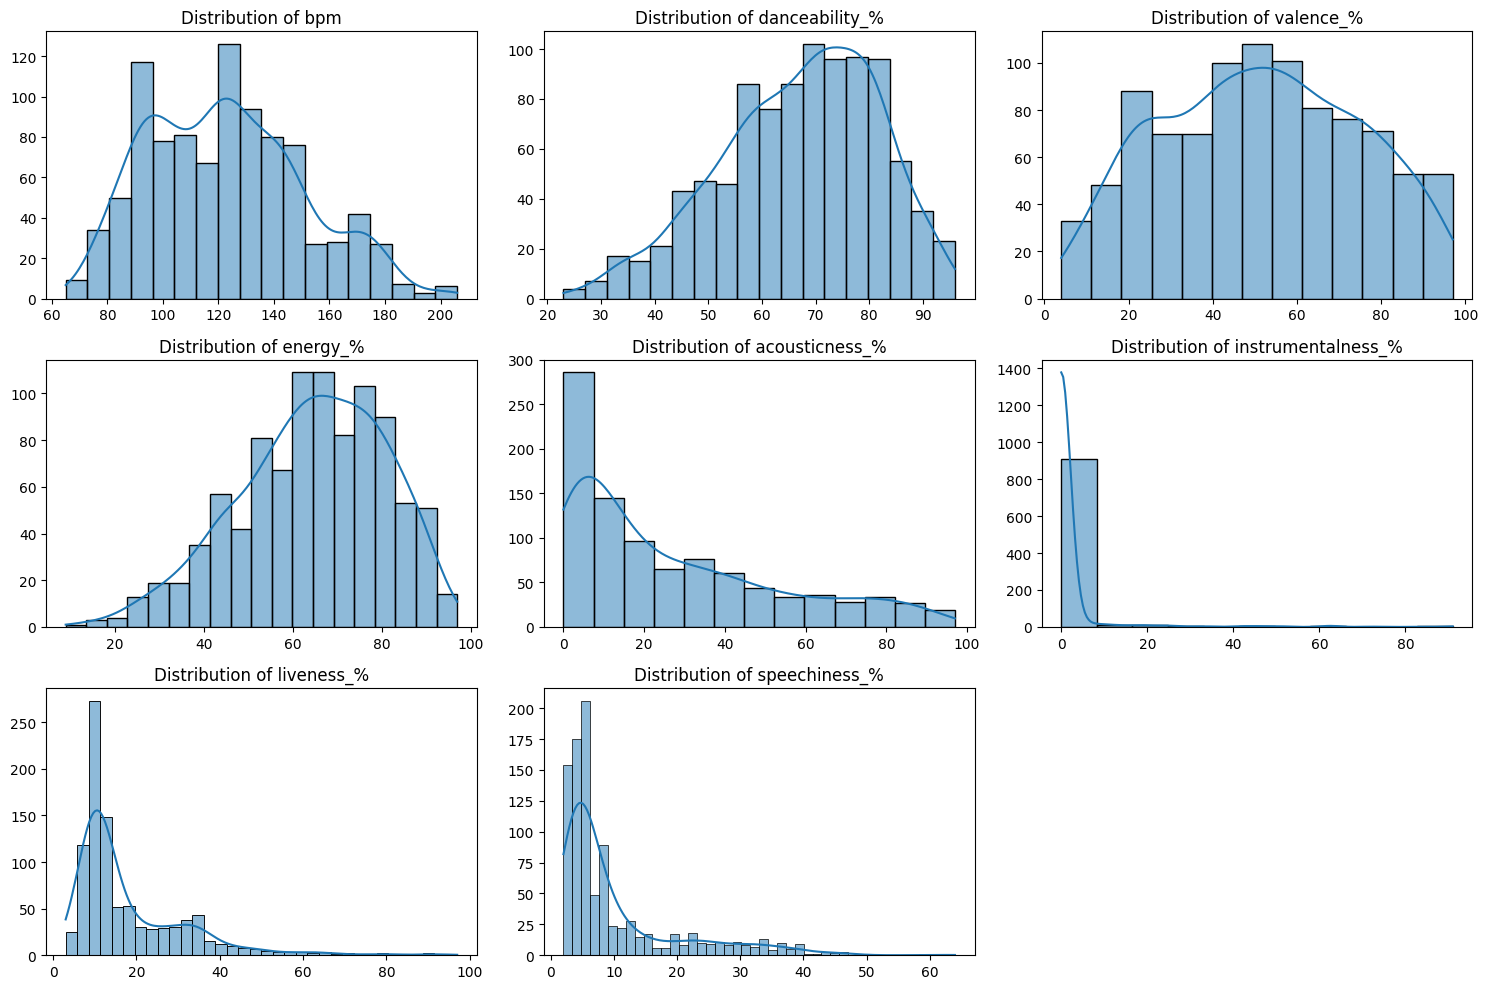

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_list):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    sns.histplot(df[feature], kde=True)  # Plot histogram with KDE
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')  # Remove x-label to avoid clutter
    plt.ylabel('')  # Remove y-label to avoid clutter

plt.tight_layout()  # Adjust layout to prevent overlapping titles
plt.show()


#**Step 9: Regression Model Evaluation & Performance Metrics**
In this step, we evaluate the predictive power of our regression model using standard performance metrics. By calculating MAE, MSE, RMSE, and the R-squared score, we can quantify the accuracy of our predictions and determine how well our features explain the variation in the number of streams.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define target variable
y = df['streams']

# Split data into training and testing sets
# Assuming X_scaled is already defined from previous steps
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model (baseline)
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Calculate R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 378251615.1381
Mean Squared Error (MSE): 247341429244813312.0000
Root Mean Squared Error (RMSE): 497334323.4131
R-squared (R2 Score): -0.0104


#**Step 10: Visualizing Model Performance**
To better understand our regression results, we use visual diagnostics. The Scatter Plot compares the actual stream counts against our model's predictions to check for correlation, while the Residuals Histogram helps us analyze the distribution of errors. A normal distribution of residuals indicates that the model is performing consistently across the dataset.

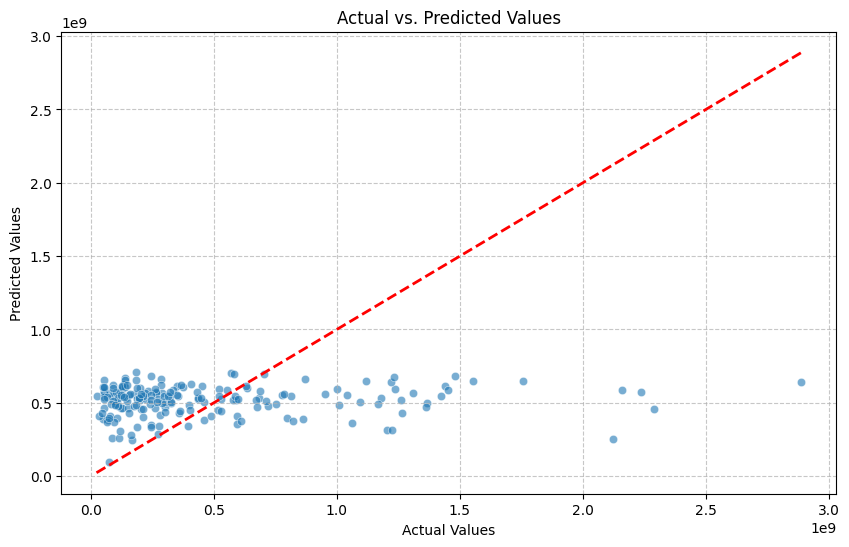

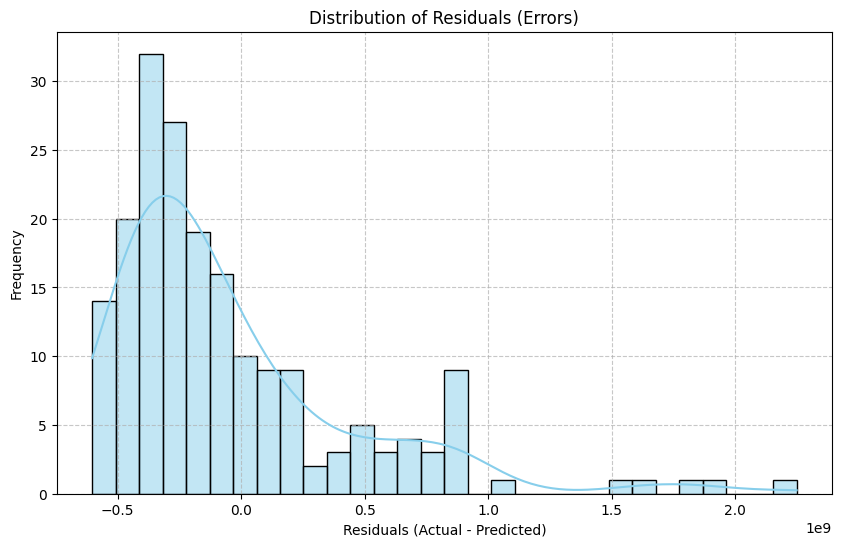

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot: Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal reference line
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Histogram of Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#**Step 11: K-Nearest Neighbors (KNN) Classification**
In this step, we transition from regression to classification using the KNN algorithm. Our goal is to classify tracks into their musical 'Mode' (Major or Minor) based on their audio features. We evaluate the model's accuracy and use a Confusion Matrix to visualize how well the algorithm distinguishes between the two categories.

KNN Accuracy Score: 0.5288

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.42      0.44        85
           1       0.57      0.61      0.59       106

    accuracy                           0.53       191
   macro avg       0.52      0.52      0.52       191
weighted avg       0.52      0.53      0.53       191



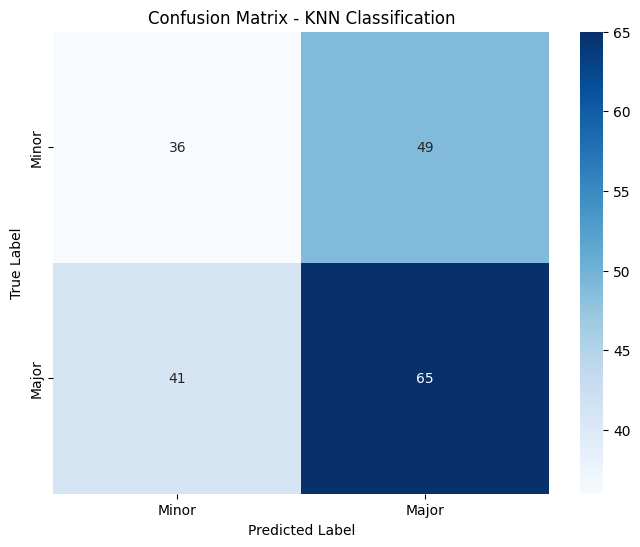

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the target variable (Encoding 'mode': Major=1, Minor=0)
y_class = df['mode'].map({'Major': 1, 'Minor': 0})

# 2. Split the data for classification
# We use X_scaled which we prepared in Step 4
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# 3. Initialize and train the KNN model
# We'll start with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)

# 4. Make predictions
y_pred_knn = knn.predict(X_test_c)

# 5. Evaluate the model
accuracy = accuracy_score(y_test_c, y_pred_knn)
print(f"KNN Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_knn))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Minor', 'Major'], yticklabels=['Minor', 'Major'])
plt.title('Confusion Matrix - KNN Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#**Step 12: Naive Bayes Classification**
In this step, we apply the Naive Bayes algorithm, a probabilistic classifier based on Bayes' Theorem. We will use it to classify tracks into 'Major' or 'Minor' modes, just as we did with KNN. This allows us to compare the performance of different classification techniques on our Spotify dataset

Naive Bayes Accuracy Score: 0.5602

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.25      0.33        85
           1       0.57      0.81      0.67       106

    accuracy                           0.56       191
   macro avg       0.54      0.53      0.50       191
weighted avg       0.55      0.56      0.52       191



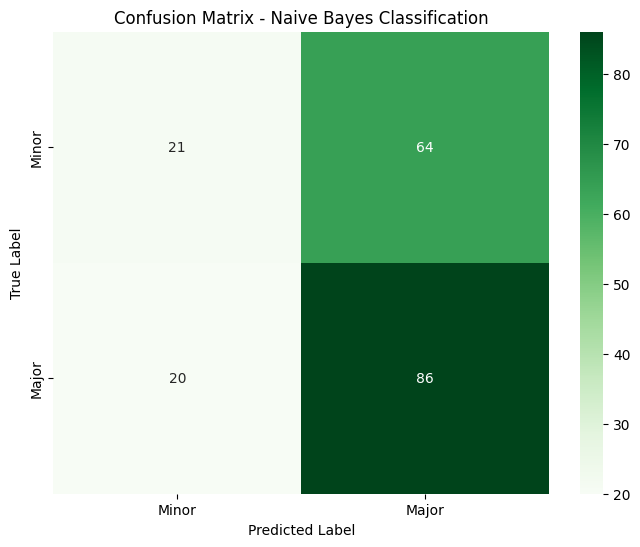

In [ ]:
from sklearn.naive_bayes import GaussianNB

# 1. Initialize and train the Naive Bayes model
# We use the same training data (X_train_c, y_train_c) from the previous step
nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c)

# 2. Make predictions
y_pred_nb = nb_model.predict(X_test_c)

# 3. Evaluate the model
accuracy_nb = accuracy_score(y_test_c, y_pred_nb)
print(f"Naive Bayes Accuracy Score: {accuracy_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_nb))

# 4. Plot Confusion Matrix
cm_nb = confusion_matrix(y_test_c, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=['Minor', 'Major'], yticklabels=['Minor', 'Major'])
plt.title('Confusion Matrix - Naive Bayes Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#**Step 13: K-Means Clustering (Unsupervised Learning)**
In this final algorithmic step, we use K-Means Clustering to group songs based on their audio similarities without using pre-defined labels. We first use the Elbow Method to find the optimal number of clusters (k) by measuring the Within-Cluster Sum of Squares (WCSS), and then we visualize how the tracks are naturally grouped.

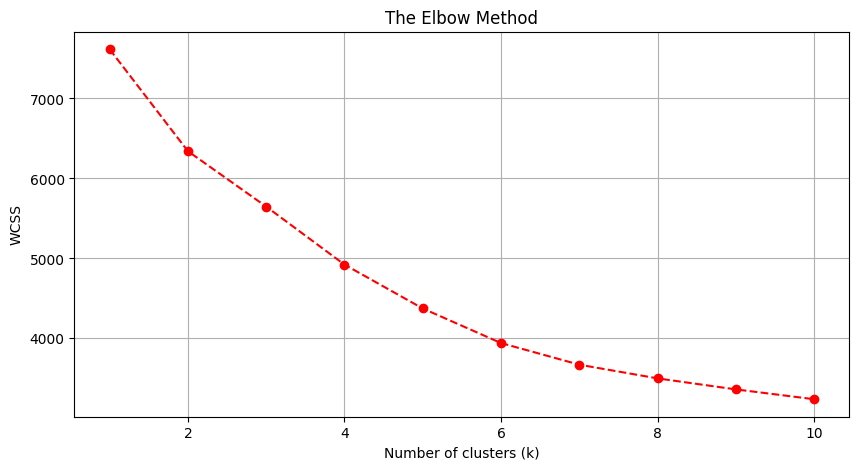

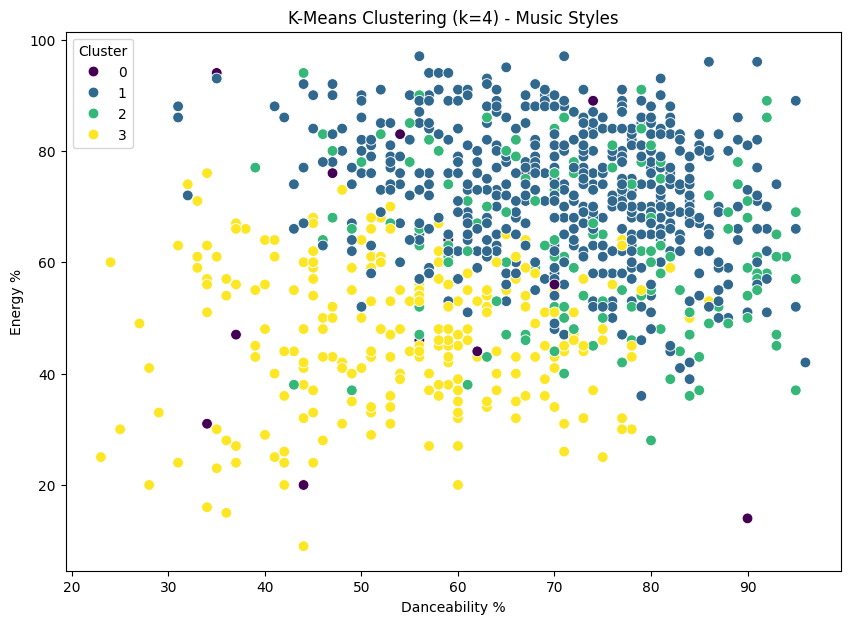

In [ ]:
from sklearn.cluster import KMeans

# 1. Using the Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 2. Applying K-Means to the dataset
# Based on the elbow plot, let's assume k=4 (you can change this based on the plot result)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 3. Add the cluster labels back to our dataframe
df['Cluster'] = clusters

# 4. Visualizing the Clusters (using Danceability vs Energy as an example)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='danceability_%', y='energy_%', hue='Cluster', palette='viridis', s=60)
plt.title(f'K-Means Clustering (k={optimal_k}) - Music Styles')
plt.xlabel('Danceability %')
plt.ylabel('Energy %')
plt.legend(title='Cluster')
plt.show()

## Demonstrating the `prepare_and_split_data` function

Here, we use the newly defined function to process the `df` DataFrame for two different tasks: predicting `mode` (classification) and predicting `streams` (regression). This showcases the function's ability to adapt to different target variables and correctly identify the appropriate machine learning task type.

In [38]:
# Example 1: Classification Task (Predicting 'mode')
print("\n--- Processing for Classification (Target: 'mode') ---")
X_train_c, y_train_c, X_val_c, y_val_c, X_test_c, y_test_c, task_c = prepare_and_split_data(
    df=df,
    target_col='mode',
    features=features_list # Using the features defined earlier
)

# Example 2: Regression Task (Predicting 'streams')
print("\n--- Processing for Regression (Target: 'streams') ---")
X_train_r, y_train_r, X_val_r, y_val_r, X_test_r, y_test_r, task_r = prepare_and_split_data(
    df=df,
    target_col='streams',
    features=features_list # Using the features defined earlier
)



--- Processing for Classification (Target: 'mode') ---
Task: Classification
Train: (667, 8), Val: (143, 8), Test: (143, 8)
Metrics: Accuracy, F1-Score, Precision/Recall, Confusion Matrix

--- Processing for Regression (Target: 'streams') ---
Task: Regression
Train: (667, 8), Val: (143, 8), Test: (143, 8)
Metrics: MAE, MSE, RMSE, R2 Score


## Step 14: Model Selection, Training, and Evaluation

In this step, we implement and evaluate machine learning models based on the detected task type. For classification tasks, we will train a Gaussian Naive Bayes model and evaluate its performance on both validation and test sets using accuracy, classification reports, and confusion matrices. Additionally, for exploratory analysis, we will perform K-Means clustering with K=2 on the training data and visualize the resulting clusters.


--- Classification Task: Gaussian Naive Bayes Model ---
Gaussian Naive Bayes model trained.

--- Naive Bayes: Validation Set Evaluation ---
Validation Accuracy: 0.6014

Validation Classification Report:
              precision    recall  f1-score   support

       Major       0.61      0.89      0.72        84
       Minor       0.55      0.19      0.28        59

    accuracy                           0.60       143
   macro avg       0.58      0.54      0.50       143
weighted avg       0.59      0.60      0.54       143



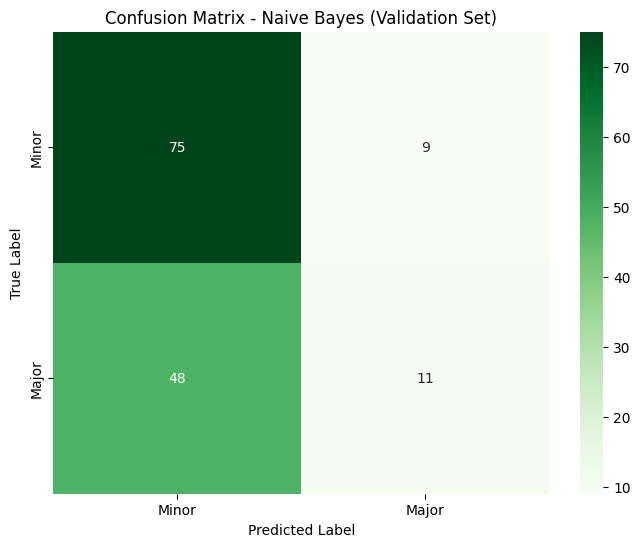


--- Naive Bayes: Test Set Evaluation ---
Test Accuracy: 0.5315

Test Classification Report:
              precision    recall  f1-score   support

       Major       0.55      0.85      0.66        78
       Minor       0.45      0.15      0.23        65

    accuracy                           0.53       143
   macro avg       0.50      0.50      0.45       143
weighted avg       0.50      0.53      0.47       143



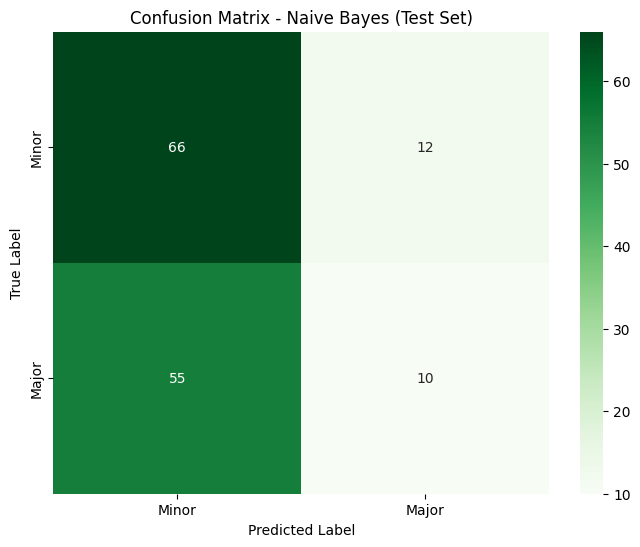

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd
import numpy as np

# Assuming task_c, X_train_c, y_train_c, X_val_c, y_val_c, X_test_c, y_test_c, and features_list are available from previous steps

if task_c == 'Classification':
    print("\n--- Classification Task: Gaussian Naive Bayes Model ---")

    # 1. Naive Bayes Model Training
    nb_model = GaussianNB()
    nb_model.fit(X_train_c, y_train_c)
    print("Gaussian Naive Bayes model trained.")

    # 2. Validation Check for Naive Bayes
    print("\n--- Naive Bayes: Validation Set Evaluation ---")
    y_pred_val_nb = nb_model.predict(X_val_c)
    accuracy_val_nb = accuracy_score(y_val_c, y_pred_val_nb)
    print(f"Validation Accuracy: {accuracy_val_nb:.4f}")
    print("\nValidation Classification Report:")
    print(classification_report(y_val_c, y_pred_val_nb))

    # Plot Confusion Matrix for Validation Set
    cm_val_nb = confusion_matrix(y_val_c, y_pred_val_nb)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_val_nb, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Minor', 'Major'], yticklabels=['Minor', 'Major'])
    plt.title('Confusion Matrix - Naive Bayes (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 3. Final Test Evaluation for Naive Bayes
    print("\n--- Naive Bayes: Test Set Evaluation ---")
    y_pred_test_nb = nb_model.predict(X_test_c)
    accuracy_test_nb = accuracy_score(y_test_c, y_pred_test_nb)
    print(f"Test Accuracy: {accuracy_test_nb:.4f}")
    print("\nTest Classification Report:")
    print(classification_report(y_test_c, y_pred_test_nb))

    # Plot Confusion Matrix for Test Set
    cm_test_nb = confusion_matrix(y_test_c, y_pred_test_nb)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_test_nb, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Minor', 'Major'], yticklabels=['Minor', 'Major'])
    plt.title('Confusion Matrix - Naive Bayes (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

else:
    print("Skipping Naive Bayes model implementation as the detected task is not 'Classification'.")



--- Unsupervised Learning: K-Means Clustering (K=2) ---
K-Means clustering performed on training data with K=2.


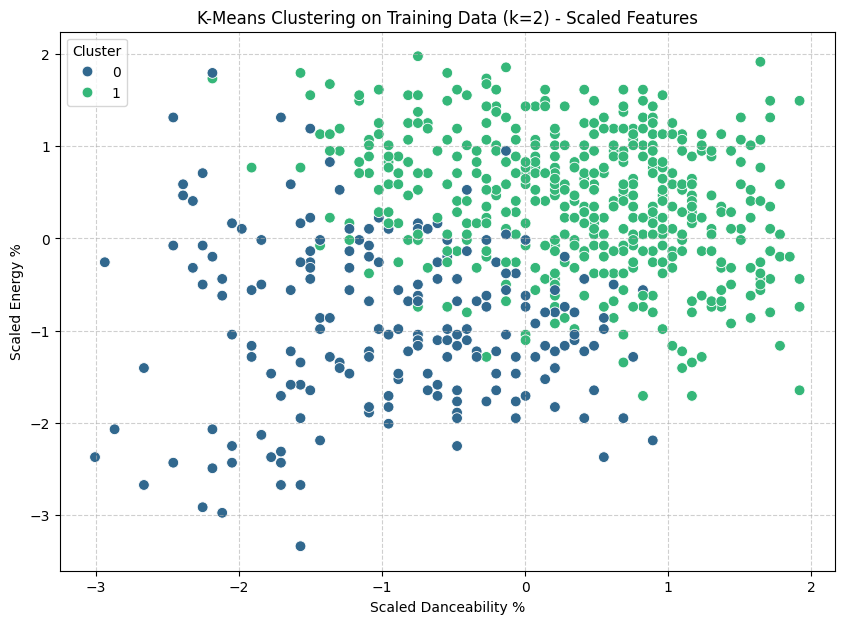

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd

# Assuming task_c, X_train_c, and features_list are available from previous steps

if task_c == 'Classification':
    print("\n--- Unsupervised Learning: K-Means Clustering (K=2) ---")

    # 1. K-Means Clustering on X_train_c with K=2
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # n_init for reproducibility
    clusters_train = kmeans.fit_predict(X_train_c)
    print("K-Means clustering performed on training data with K=2.")

    # 2. Visualize Cluster Assignments
    # Create a DataFrame from X_train_c with original feature names for plotting
    X_train_df_for_plot = pd.DataFrame(X_train_c, columns=features_list)
    X_train_df_for_plot['Cluster'] = clusters_train

    plt.figure(figsize=(10, 7))
    # Using 'danceability_%' and 'energy_%' as examples for plotting
    sns.scatterplot(data=X_train_df_for_plot, x='danceability_%', y='energy_%', hue='Cluster', palette='viridis', s=60)
    plt.title('K-Means Clustering on Training Data (k=2) - Scaled Features')
    plt.xlabel('Scaled Danceability %')
    plt.ylabel('Scaled Energy %')
    plt.legend(title='Cluster')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Skipping K-Means clustering as the detected task is not 'Classification'.")


#***Project Conclusion & Summary***

In this project, we successfully navigated the full Data Science pipeline. Starting from Data Cleaning and Exploratory Data Analysis (EDA), we prepared our Spotify dataset for advanced analytics. 📊

##***Key Achievements:***

##***Regression Analysis:***

We implemented a Linear Regression model to predict song streams and evaluated its performance using metrics like MAE, MSE, and RMSE.

##***Classification:***

 We applied KNN and Naive Bayes to classify tracks into 'Major' or 'Minor' modes, visualizing results through Confusion Matrices.

##***Clustering:***

 We used K-Means Clustering to discover hidden patterns and group songs based on their unique audio characteristics.

#***🚀Future Work & Project Development 🌟***

Every great data project is just the beginning! To take this analysis to the next level, here are several ways we can enhance our models:

###**1. Sentiment Analysis 🎭**


Lyrics Integration: Analyzing if the emotional tone of lyrics (Positive vs. Negative) correlates with song popularity.

###**2. Time Series Analysis 📅**

**Trends Over Time**: Studying how musical features evolve seasonally or annually to identify shifting trends in the industry.

###**3. Web App Deployment 🌐**

**Interactive Tool**: Using Streamlit to create a web-based dashboard where users can input audio features and get instant stream predictions.

###**4. Deep Learning Implementation 🧠**

**Neural Networks**: Moving beyond traditional ML to apply Artificial Neural Networks (ANN) for potentially higher predictive accuracy.

###**5. Music Recommendation System 🎵**
**Personalized Suggestions**:Building a recommendation engine that suggests new tracks to users based on the "Clusters" we identified.


###**Prepared by:**

**🌙Hala alkhawaldeh** &

**🌚Abdallah alsharkawi**
